# Étape 5 : Interprétation et Visualisation

Ce notebook analyse le dataset enrichi (CVE, CVSS, EPSS, risk score) pour identifier les vulnérabilités critiques, les produits les plus impactés et les menaces à forte probabilité d'exploitation.

## 1. Imports et chargement des données

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("final_risk_prioritization.csv", sep=";", low_memory=False)

df["Date"]           = pd.to_datetime(df["Date"], errors="coerce")
df["CVSS"]           = pd.to_numeric(df["CVSS"],           errors="coerce")
df["EPSS"]           = pd.to_numeric(df["EPSS"],           errors="coerce")
df["CVSS_completed"] = pd.to_numeric(df["CVSS_completed"], errors="coerce")
df["EPSS_completed"] = pd.to_numeric(df["EPSS_completed"], errors="coerce")
df["risk_score"]     = pd.to_numeric(df["risk_score"],     errors="coerce")

# Nettoyage colonnes éditeur / produit (peut contenir "Linux, Linux")
df["Editeur_clean"] = df["Editeur"].str.split(",").str[0].str.strip()
df["Produit_clean"] = df["Produit"].str.split(",").str[0].str.strip()

print(f"Shape : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Période : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"CVE uniques : {df['CVE'].nunique()}")
df.head()


Shape : 125372 lignes, 18 colonnes
Période : 2021-02-02 → 2026-06-09
CVE uniques : 36795


,ID ANSSI,Titre ANSSI,Type,Date,CVE,Editeur,Produit,Versions affectées,CVSS,CVSS_completed,EPSS,EPSS_completed,risk_score,risk_priority,Lien CVE,Lien solution,Editeur_clean,Produit_clean
0,CERTFR-2023-ALE-009,[MàJ] Multiples vulnérabilités dans Ivanti End...,Alerte,2023-07-26,CVE-2023-35078,Ivanti,Endpoint Manager Mobile,NaN,10.0,10.0,0.94482,0.94482,0.977928,CRITICAL,https://www.cve.org/CVERecord?id=CVE-2023-35078,https://forums.ivanti.com/s/article/CVE-2023-3...,Ivanti,Endpoint Manager Mobile
1,CERTFR-2023-AVI-0584,Vulnérabilité dans Ivanti Endpoint Manager Mobile,Avis,2023-07-25,CVE-2023-35078,Ivanti,Endpoint Manager Mobile,NaN,10.0,10.0,0.94482,0.94482,0.977928,CRITICAL,https://www.cve.org/CVERecord?id=CVE-2023-35078,https://forums.ivanti.com/s/article/CVE-2023-3...,Ivanti,Endpoint Manager Mobile
2,CERTFR-2023-AVI-0604,Vulnérabilité dans Ivanti Endpoint Manager Mobile,Avis,2023-07-31,CVE-2023-35078,Ivanti,Endpoint Manager Mobile,NaN,10.0,10.0,0.94482,0.94482,0.977928,CRITICAL,https://www.cve.org/CVERecord?id=CVE-2023-35078,https://forums.ivanti.com/s/article/CVE-2023-3...,Ivanti,Endpoint Manager Mobile
3,CERTFR-2023-AVI-0793,Multiples vulnérabilités dans Progress WS_FTP ...,Avis,2023-09-29,CVE-2023-40044,Progress Software Corporation,WS_FTP Server,"8.8.0, 8.7.0",10.0,10.0,0.94449,0.94449,0.977796,CRITICAL,https://www.cve.org/CVERecord?id=CVE-2023-40044,https://community.progress.com/s/article/WS-FT...,Progress Software Corporation,WS_FTP Server
4,CERTFR-2021-ALE-018,Vulnérabilité dans Atlassian Confluence Server...,Alerte,2021-09-06,CVE-2021-26084,"Atlassian, Atlassian","Confluence Server, Confluence Data Center","unspecified, 6.14.0, unspecified, 7.5.0, unspe...",NaN,10.0,0.94440,0.94440,0.977760,CRITICAL,https://www.cve.org/CVERecord?id=CVE-2021-26084,https://jira.atlassian.com/browse/CONFSERVER-6...,Atlassian,Confluence Server


## 2. Aperçu général du dataset

In [4]:
print("Répartition Alertes / Avis :")
print(df["Type"].value_counts())
print()
print("Répartition par priorité de risque :")
print(df["risk_priority"].value_counts())
print()
print("Valeurs manquantes :")
print(df.isna().sum()[df.isna().sum() > 0])


Répartition Alertes / Avis :
Type
Avis      125211
Alerte       161
Name: count, dtype: int64

Répartition par priorité de risque :
risk_priority
MEDIUM      117998
LOW           5593
HIGH          1049
CRITICAL       732
Name: count, dtype: int64

Valeurs manquantes :
Versions affectées     9192
CVSS                  96091
EPSS                    763
dtype: int64


## 3. Distribution des scores CVSS

Le score CVSS (0-10) indique la gravité technique d'une vulnérabilité. On utilise `CVSS_completed` qui comble les valeurs manquantes via le modèle ML.

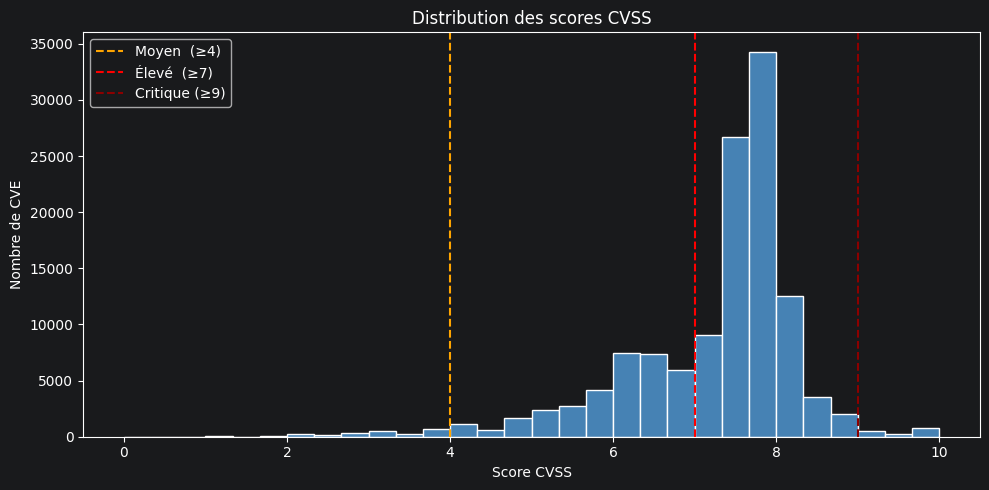

Moyenne : 7.24  |  Médiane : 7.60  |  Max : 10.0
CVE critiques (CVSS ≥ 9) : 1544 (1.2%)


In [5]:
plt.figure(figsize=(10, 5))
plt.hist(df["CVSS_completed"].dropna(), bins=30, color="steelblue", edgecolor="white")
plt.axvline(x=4, color="orange",  linestyle="--", linewidth=1.5, label="Moyen  (≥4)")
plt.axvline(x=7, color="red",     linestyle="--", linewidth=1.5, label="Élevé  (≥7)")
plt.axvline(x=9, color="darkred", linestyle="--", linewidth=1.5, label="Critique (≥9)")
plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS")
plt.ylabel("Nombre de CVE")
plt.legend()
plt.tight_layout()
plt.show()

# Stats rapides
cvss = df["CVSS_completed"].dropna()
print(f"Moyenne : {cvss.mean():.2f}  |  Médiane : {cvss.median():.2f}  |  Max : {cvss.max():.1f}")
print(f"CVE critiques (CVSS ≥ 9) : {(cvss >= 9).sum()} ({(cvss >= 9).mean()*100:.1f}%)")


## 4. Répartition par niveau de priorité

Le `risk_priority` est calculé à partir du `risk_score` (combinaison CVSS × EPSS) par le modèle ML.

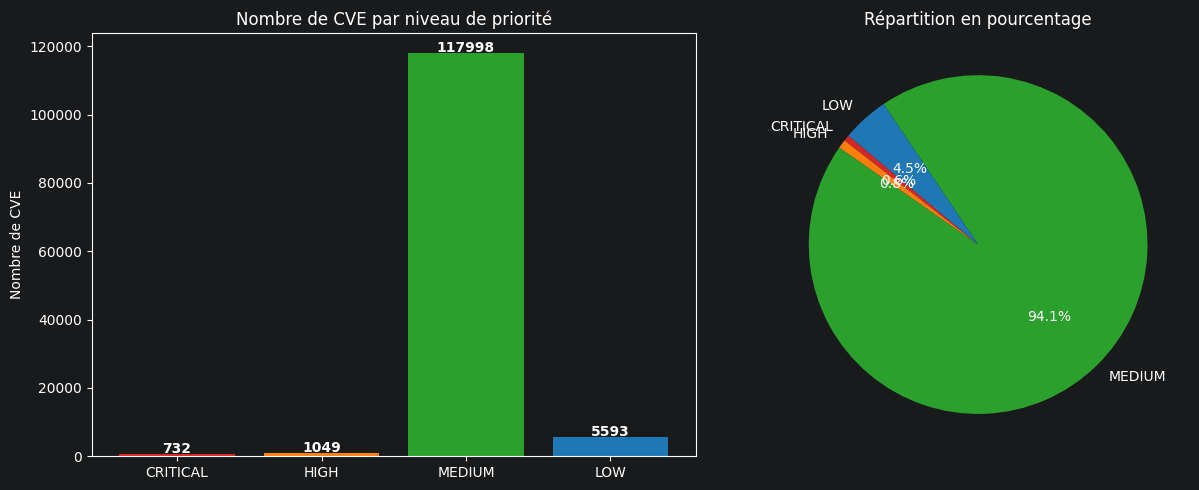

In [6]:
ordre    = ["CRITICAL", "HIGH", "MEDIUM", "LOW"]
couleurs = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
counts   = df["risk_priority"].value_counts().reindex(ordre, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Graphique en barres
bars = axes[0].bar(counts.index, counts.values, color=couleurs)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                 str(val), ha="center", fontweight="bold")
axes[0].set_title("Nombre de CVE par niveau de priorité")
axes[0].set_ylabel("Nombre de CVE")

# Diagramme circulaire
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=couleurs, startangle=140)
axes[1].set_title("Répartition en pourcentage")

plt.tight_layout()
plt.show()


## 5. Courbe des scores EPSS

L'EPSS (0-1) estime la probabilité qu'une CVE soit exploitée. La plupart des CVE ont un EPSS très faible, mais quelques-unes sont très dangereuses.

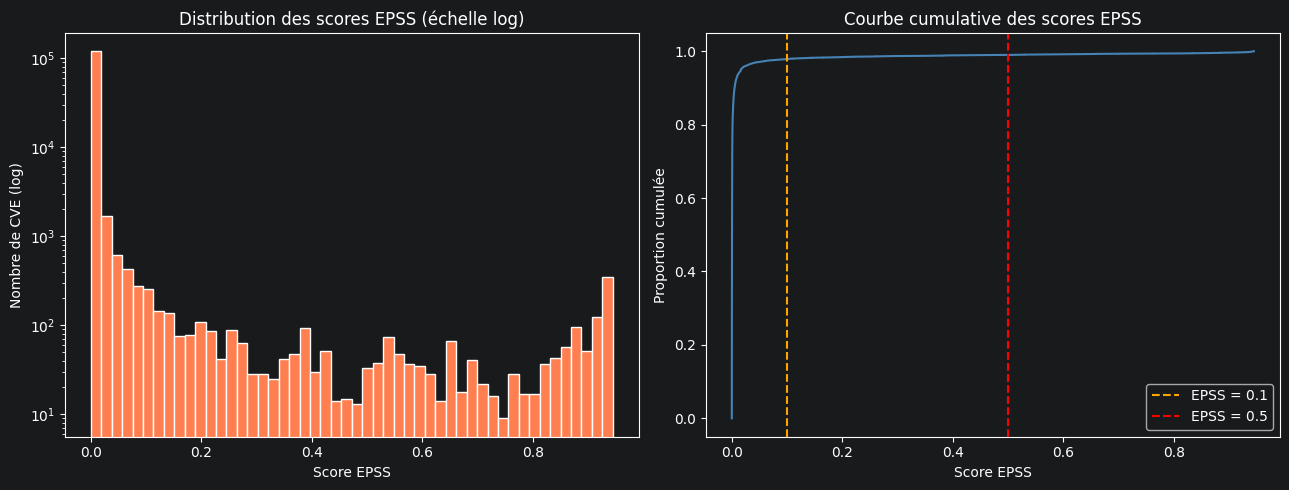

CVE avec EPSS ≥ 0.1 : 2659 (2.1%)
CVE avec EPSS ≥ 0.5 : 1278 (1.0%)


In [7]:
epss = df["EPSS_completed"].dropna().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme (échelle log pour voir les petites valeurs)
axes[0].hist(epss, bins=50, color="coral", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Distribution des scores EPSS (échelle log)")
axes[0].set_xlabel("Score EPSS")
axes[0].set_ylabel("Nombre de CVE (log)")

# Courbe cumulative (CDF)
cdf = np.arange(1, len(epss) + 1) / len(epss)
axes[1].plot(epss.values, cdf, color="steelblue", linewidth=1.5)
axes[1].axvline(0.1, color="orange", linestyle="--", label="EPSS = 0.1")
axes[1].axvline(0.5, color="red",    linestyle="--", label="EPSS = 0.5")
axes[1].set_title("Courbe cumulative des scores EPSS")
axes[1].set_xlabel("Score EPSS")
axes[1].set_ylabel("Proportion cumulée")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"CVE avec EPSS ≥ 0.1 : {(epss >= 0.1).sum()} ({(epss >= 0.1).mean()*100:.1f}%)")
print(f"CVE avec EPSS ≥ 0.5 : {(epss >= 0.5).sum()} ({(epss >= 0.5).mean()*100:.1f}%)")


## 6. Nuage de points CVSS vs EPSS

Une CVE peut être grave (CVSS élevé) sans être exploitée activement, et vice versa. Ce graphe met en évidence cette distinction.

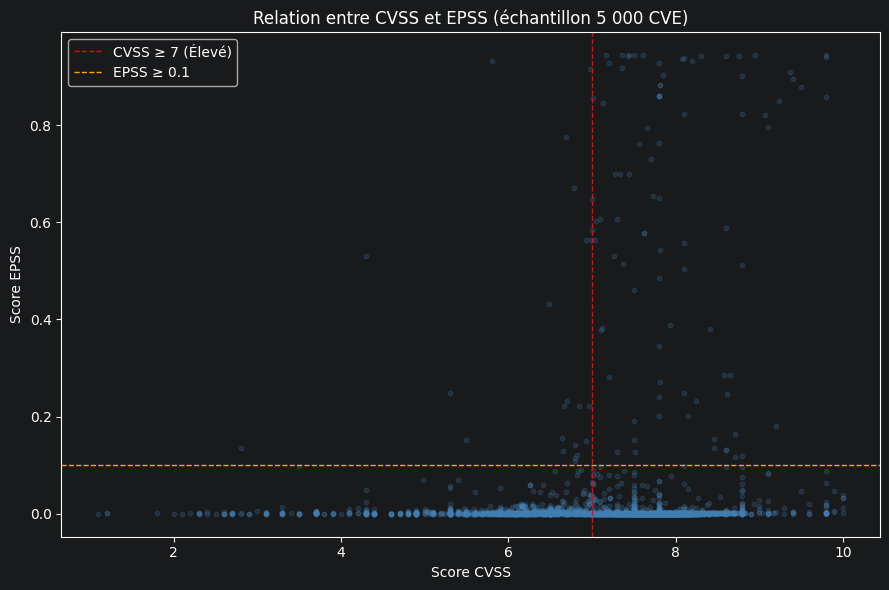

Corrélation CVSS / EPSS : 0.074
→ Une faible corrélation confirme que gravité et exploitation sont deux dimensions indépendantes.


In [8]:
sample = df[["CVSS_completed", "EPSS_completed"]].dropna().sample(n=5000, random_state=42)

plt.figure(figsize=(9, 6))
plt.scatter(sample["CVSS_completed"], sample["EPSS_completed"],
            alpha=0.2, s=10, color="steelblue")
plt.axvline(x=7, color="red",    linestyle="--", linewidth=1, label="CVSS ≥ 7 (Élevé)")
plt.axhline(y=0.1, color="orange", linestyle="--", linewidth=1, label="EPSS ≥ 0.1")
plt.title("Relation entre CVSS et EPSS (échantillon 5 000 CVE)")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.legend()
plt.tight_layout()
plt.show()

# Corrélation
corr = df[["CVSS_completed", "EPSS_completed"]].corr().iloc[0, 1]
print(f"Corrélation CVSS / EPSS : {corr:.3f}")
print("->Une faible corrélation confirme que gravité et exploitation sont deux dimensions indépendantes.")


## 7. Heatmap des corrélations

On visualise les corrélations entre les scores numériques avec `matplotlib` (pas besoin de seaborn).

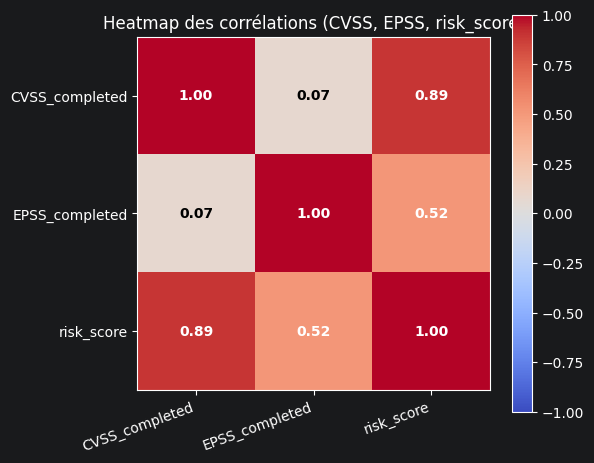

In [9]:
num_cols = ["CVSS_completed", "EPSS_completed", "risk_score"]
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=20, ha="right")
ax.set_yticklabels(num_cols)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}",
                ha="center", va="center", fontweight="bold",
                color="white" if abs(corr_matrix.values[i, j]) > 0.5 else "black")

ax.set_title("Heatmap des corrélations (CVSS, EPSS, risk_score)")
plt.tight_layout()
plt.show()


## 8. Alertes vs Avis

Les **Alertes** concernent des vulnérabilités activement exploitées — on s'attend donc à un CVSS moyen plus élevé.

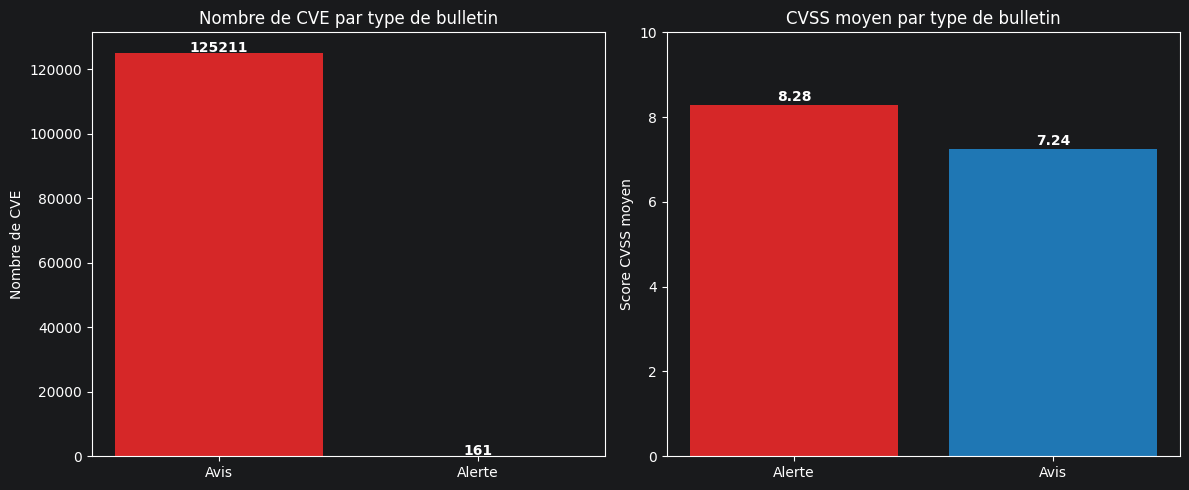

In [10]:
type_counts  = df["Type"].value_counts()
cvss_by_type = df.groupby("Type")["CVSS_completed"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Nombre de CVE
axes[0].bar(type_counts.index, type_counts.values, color=["#d62728", "#1f77b4"])
for i, val in enumerate(type_counts.values):
    axes[0].text(i, val + 300, str(val), ha="center", fontweight="bold")
axes[0].set_title("Nombre de CVE par type de bulletin")
axes[0].set_ylabel("Nombre de CVE")

# CVSS moyen
axes[1].bar(cvss_by_type.index, cvss_by_type.values, color=["#d62728", "#1f77b4"])
for i, val in enumerate(cvss_by_type.values):
    axes[1].text(i, val + 0.1, f"{val:.2f}", ha="center", fontweight="bold")
axes[1].set_title("CVSS moyen par type de bulletin")
axes[1].set_ylabel("Score CVSS moyen")
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()


## 9. Éditeurs les plus affectés

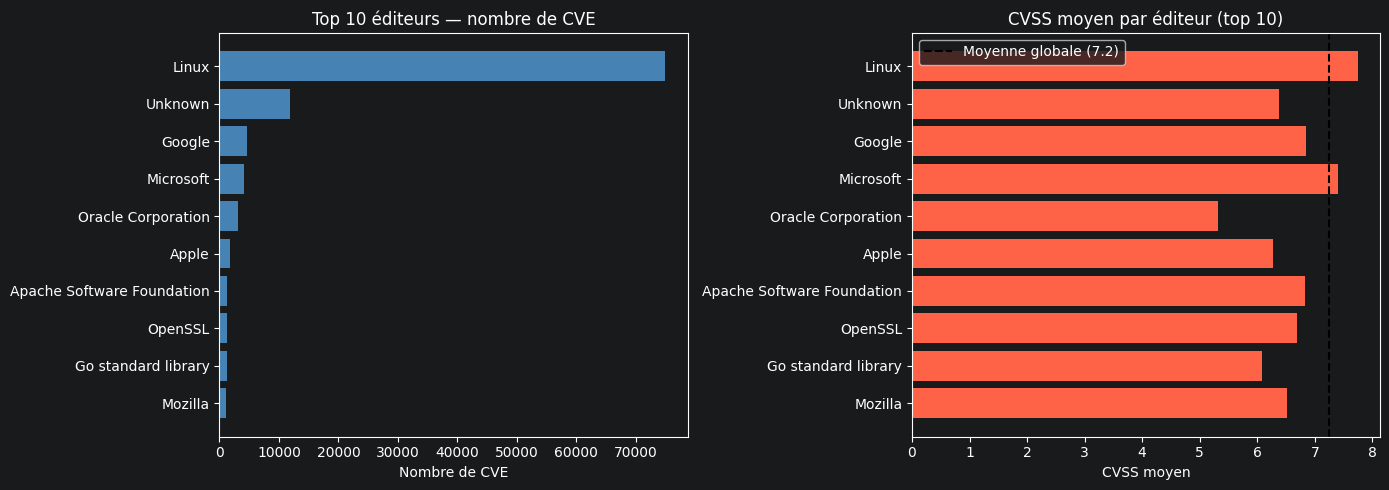

In [11]:
top_editeurs = df["Editeur_clean"].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart nombre de CVE
axes[0].barh(top_editeurs.index[::-1], top_editeurs.values[::-1], color="steelblue")
axes[0].set_title("Top 10 éditeurs — nombre de CVE")
axes[0].set_xlabel("Nombre de CVE")

# CVSS moyen par éditeur (top 10)
cvss_editeur = (df[df["Editeur_clean"].isin(top_editeurs.index)]
                .groupby("Editeur_clean")["CVSS_completed"]
                .mean()
                .reindex(top_editeurs.index))
axes[1].barh(cvss_editeur.index[::-1], cvss_editeur.values[::-1], color="tomato")
axes[1].axvline(df["CVSS_completed"].mean(), color="black", linestyle="--",
                label=f"Moyenne globale ({df['CVSS_completed'].mean():.1f})")
axes[1].set_title("CVSS moyen par éditeur (top 10)")
axes[1].set_xlabel("CVSS moyen")
axes[1].legend()

plt.tight_layout()
plt.show()


## 10. Boxplot des scores CVSS par éditeur

Le boxplot montre la dispersion des scores CVSS pour chaque éditeur, pas seulement la moyenne.

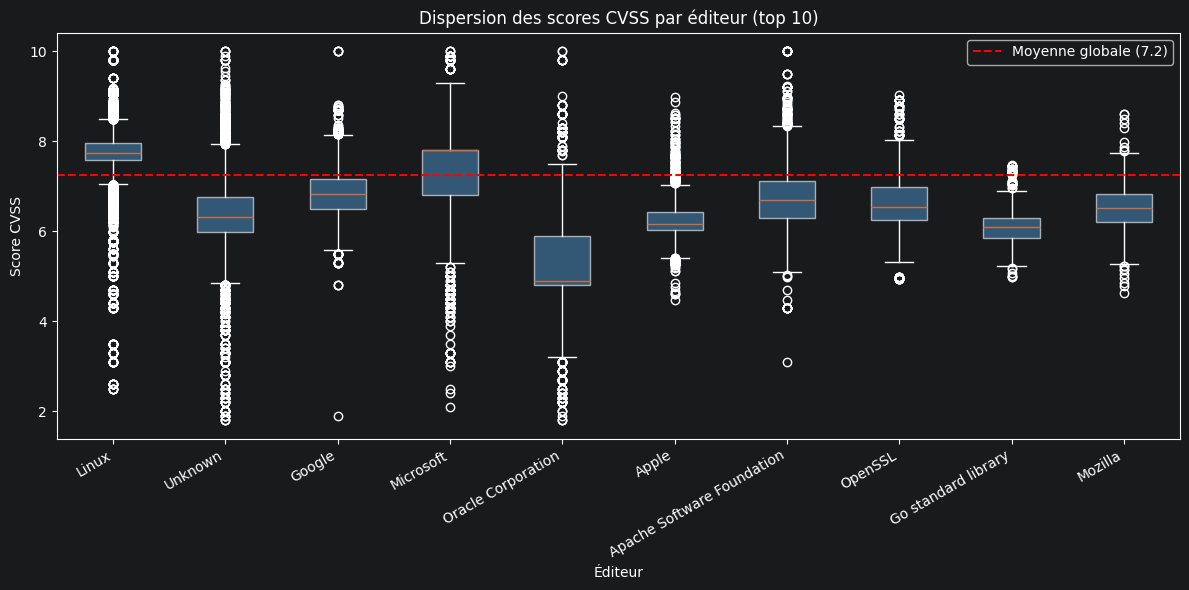

In [12]:
top10_noms = df["Editeur_clean"].value_counts().head(10).index.tolist()
df_box = df[df["Editeur_clean"].isin(top10_noms)]

# Préparer les données pour le boxplot matplotlib
data_box = [df_box[df_box["Editeur_clean"] == e]["CVSS_completed"].dropna().values
            for e in top10_noms]

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(data_box, labels=top10_noms, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6))
ax.axhline(df["CVSS_completed"].mean(), color="red", linestyle="--",
           label=f"Moyenne globale ({df['CVSS_completed'].mean():.1f})")
ax.set_title("Dispersion des scores CVSS par éditeur (top 10)")
ax.set_ylabel("Score CVSS")
ax.set_xlabel("Éditeur")
plt.xticks(rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.show()


## 11. Produits les plus vulnérables

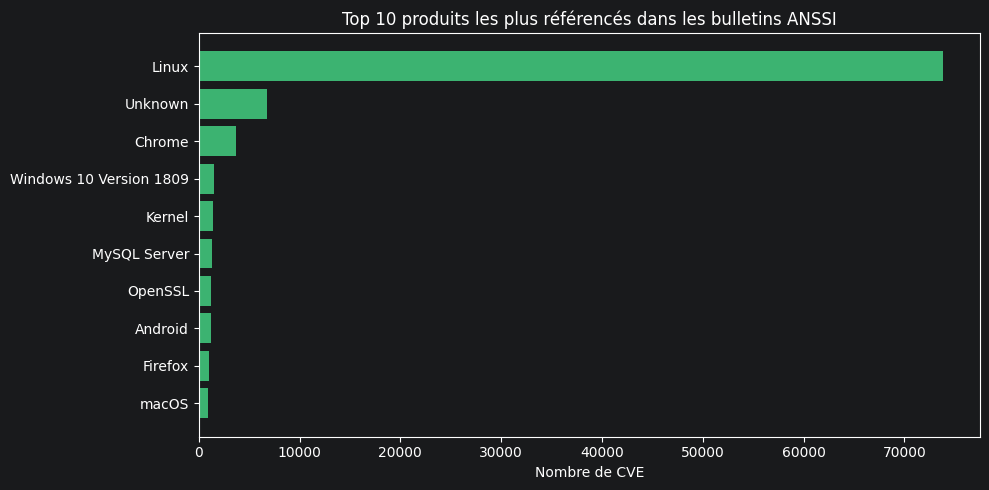

In [13]:
top_produits = df["Produit_clean"].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_produits.index[::-1], top_produits.values[::-1], color="mediumseagreen")
plt.title("Top 10 produits les plus référencés dans les bulletins ANSSI")
plt.xlabel("Nombre de CVE")
plt.tight_layout()
plt.show()


## 12. Évolution temporelle des vulnérabilités

On trace l'évolution mensuelle du nombre de CVE détectées et la courbe cumulative.

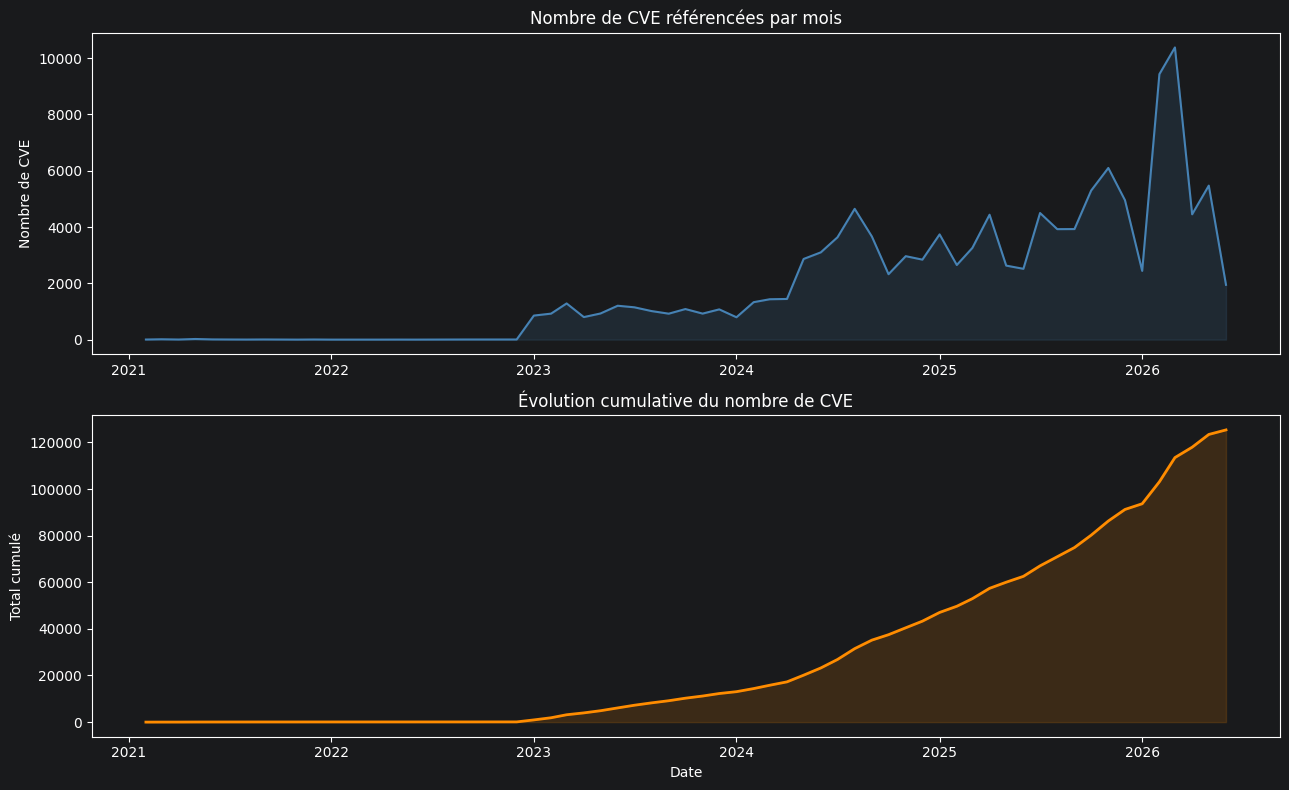

In [14]:
df_time = df.dropna(subset=["Date"]).copy()
monthly = df_time.groupby(df_time["Date"].dt.to_period("M")).size()
monthly.index = monthly.index.to_timestamp()
cumul = monthly.cumsum()

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(monthly.index, monthly.values, color="steelblue", linewidth=1.5)
axes[0].fill_between(monthly.index, monthly.values, alpha=0.15, color="steelblue")
axes[0].set_title("Nombre de CVE référencées par mois")
axes[0].set_ylabel("Nombre de CVE")

axes[1].plot(cumul.index, cumul.values, color="darkorange", linewidth=2)
axes[1].fill_between(cumul.index, cumul.values, alpha=0.15, color="darkorange")
axes[1].set_title("Évolution cumulative du nombre de CVE")
axes[1].set_ylabel("Total cumulé")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()


## 13. Nombre de vulnérabilités par éditeur — Alertes vs Avis

On distingue pour chaque éditeur la part d'Alertes (exploitation active) vs d'Avis.

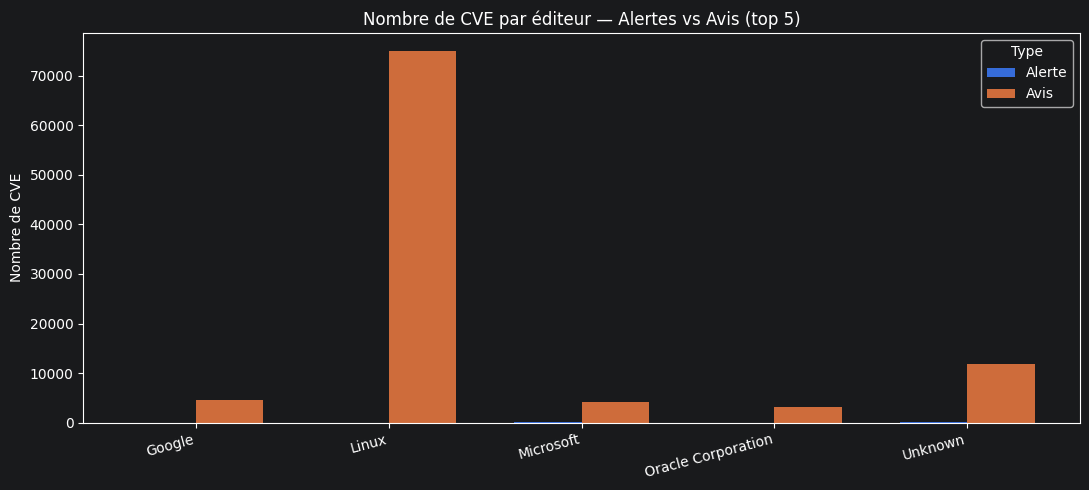

In [15]:
top5_noms = df["Editeur_clean"].value_counts().head(5).index.tolist()
df_type = df[df["Editeur_clean"].isin(top5_noms)]
pivot = df_type.groupby(["Editeur_clean", "Type"]).size().unstack(fill_value=0)

x = np.arange(len(pivot))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
for i, col in enumerate(pivot.columns):
    offset = (i - len(pivot.columns) / 2 + 0.5) * width
    bars = ax.bar(x + offset, pivot[col], width, label=col)

ax.set_title("Nombre de CVE par éditeur — Alertes vs Avis (top 5)")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=15, ha="right")
ax.set_ylabel("Nombre de CVE")
ax.legend(title="Type")
plt.tight_layout()
plt.show()


## 14. Top 20 CVE les plus dangereuses (CVSS × EPSS)

On combine CVSS et EPSS pour identifier les CVE qui sont à la fois graves **et** activement exploitées.

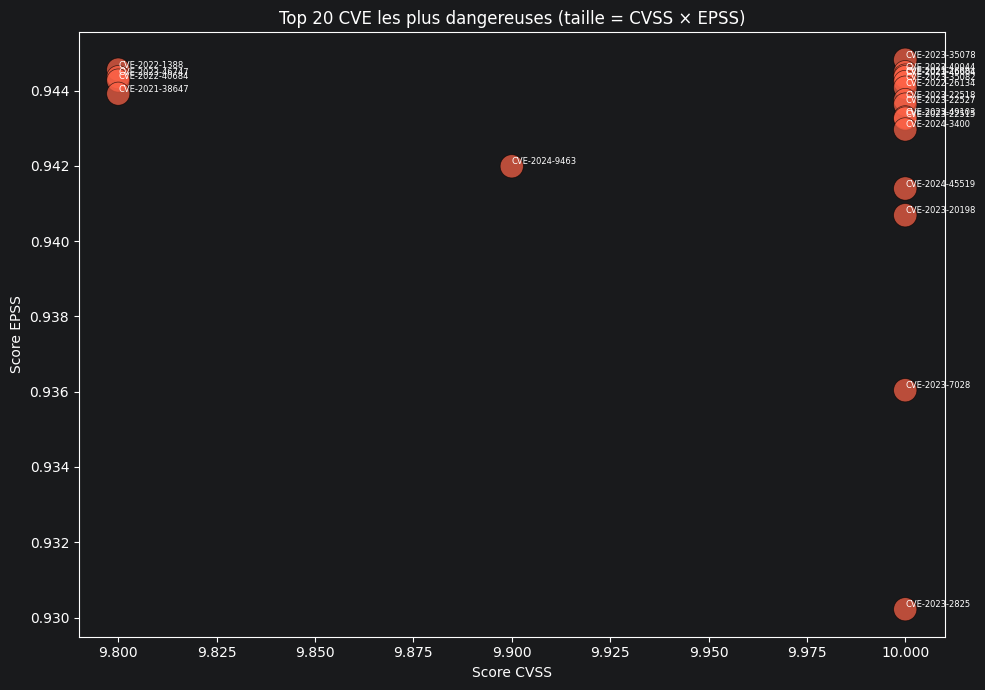

,CVE,Produit_clean,CVSS_completed,EPSS_completed,danger_score
0,CVE-2023-35078,Endpoint Manager Mobile,10.0,0.94482,9.448200
1,CVE-2023-40044,WS_FTP Server,10.0,0.94449,9.444900
2,CVE-2021-26084,Confluence Server,10.0,0.94440,9.444000
3,CVE-2023-46604,Apache ActiveMQ,10.0,0.94436,9.443600
4,CVE-2023-35082,EPMM,10.0,0.94423,9.442300
5,CVE-2022-26134,Confluence Data Center,10.0,0.94408,9.440800
6,CVE-2023-22518,Confluence Data Center,10.0,0.94375,9.437500
7,CVE-2023-22527,Confluence Data Center,10.0,0.94363,9.436300
8,CVE-2023-49103,Unknown,10.0,0.94329,9.432900
9,CVE-2023-22515,Confluence Data Center,10.0,0.94326,9.432600


In [16]:
df_top = (df[["CVE", "Produit_clean", "CVSS_completed", "EPSS_completed"]]
          .dropna(subset=["CVSS_completed", "EPSS_completed"])
          .drop_duplicates("CVE")
          .copy())
df_top["danger_score"] = df_top["CVSS_completed"] * df_top["EPSS_completed"]
top20 = df_top.nlargest(20, "danger_score")

plt.figure(figsize=(10, 7))
plt.scatter(
    top20["CVSS_completed"], top20["EPSS_completed"],
    s=top20["danger_score"] * 30,
    color="tomato", alpha=0.7, edgecolors="black", linewidth=0.5
)
for _, row in top20.iterrows():
    plt.annotate(row["CVE"],
                 (row["CVSS_completed"], row["EPSS_completed"]),
                 fontsize=6, ha="left", va="bottom")
plt.title("Top 20 CVE les plus dangereuses (taille = CVSS × EPSS)")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.tight_layout()
plt.show()

top20[["CVE", "Produit_clean", "CVSS_completed", "EPSS_completed", "danger_score"]].reset_index(drop=True)


## 15. Synthèse et conclusions

Les visualisations précédentes permettent de tirer plusieurs conclusions :

- **CVSS et EPSS sont faiblement corrélés** : une vulnérabilité grave techniquement n'est pas forcément exploitée activement. Il faut combiner les deux indicateurs pour prioriser efficacement.
- **Les Alertes ANSSI** (exploitation active) ont un CVSS moyen nettement plus élevé que les Avis, ce qui est cohérent avec leur nature urgente.
- **La majorité des CVE** a un EPSS très faible (< 0.01), mais une minorité à EPSS élevé concentre le risque réel — la courbe cumulative EPSS l'illustre clairement.
- **Linux et Google** dominent les éditeurs en volume de CVE, mais leur CVSS moyen n'est pas nécessairement le plus élevé.
- **Le `risk_score` (CVSS × EPSS)** est un bon indicateur synthétique pour prioriser les actions de remédiation.
